# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Rizqi maulidiyah 
- **Email:** elkanaxafier@gmail.com
- **ID Dicoding:** 

## Menentukan Pertanyaan Bisnis


- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi dan bagaimana tren penjualannya per bulan?
- **Pertanyaan 2:** Bagaimana distribusi skor ulasan (review score) pelanggan dan apakah waktu pengiriman mempengaruhi kepuasan pelanggan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')



## Data Wrangling

### Gathering Data

In [2]:
#Load dataset E-Commerce
orders_df = pd.read_csv('E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('E-Commerce Public Dataset/order_items_dataset.csv')
order_payments_df = pd.read_csv('E-Commerce Public Dataset/order_payments_dataset.csv')
order_reviews_df = pd.read_csv('E-Commerce Public Dataset/order_reviews_dataset.csv')
products_df = pd.read_csv('E-Commerce Public Dataset/products_dataset.csv')
product_category_df = pd.read_csv('E-Commerce Public Dataset/product_category_name_translation.csv')
customers_df = pd.read_csv('E-Commerce Public Dataset/customers_dataset.csv')

print('Dataset berhasil dimuat!')
print(f'Orders         : {orders_df.shape}')
print(f'Order Items    : {order_items_df.shape}')
print(f'Order Payments : {order_payments_df.shape}')
print(f'Order Reviews  : {order_reviews_df.shape}')
print(f'Products       : {products_df.shape}')
print(f'Customers      : {customers_df.shape}')

Dataset berhasil dimuat!
Orders         : (99441, 8)
Order Items    : (112650, 7)
Order Payments : (103886, 5)
Order Reviews  : (99224, 7)
Products       : (32951, 9)
Customers      : (99441, 5)


In [3]:
# 5 baris pertama tiap dataset
print('Orders Dataset')
display(orders_df.head())

print('\nOrder Items Dataset ')
display(order_items_df.head())

print('\nOrder Reviews Dataset ')
display(order_reviews_df.head())

Orders Dataset


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Order Items Dataset 


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Order Reviews Dataset 


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
#### Dataset E-Commerce terdiri dari beberapa tabel yang saling berhubungan melalui `order_id` dan `product_id`.
- Tabel orders menyimpan informasi waktu pemesanan dan status pengiriman, yang dapat digunakan untuk menghitung durasi pengiriman.
- Tabel order_items memberikan detail harga dan biaya pengiriman, memungkinkan analisis nilai transaksi.
- Tabel order_reviews menyediakan skor kepuasan pelanggan.
#### Dengan menggabungkan tabel-tabel ini, dapat dianalisis:
- Hubungan antara waktu pengiriman dan kepuasan pelanggan (review_score)
- Pengaruh harga dan ongkir terhadap rating
- Pola performa pengiriman berdasarkan waktu

### Assessing Data

In [4]:
# Cek missing values
print(' Missing Values per Dataset')
datasets = {
    'orders': orders_df,
    'order_items': order_items_df,
    'order_payments': order_payments_df,
    'order_reviews': order_reviews_df,
    'products': products_df
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'\n{name}:')
        print(missing)

 Missing Values per Dataset

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

order_reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [5]:
print('Tipe Data Orders')
print(orders_df.dtypes)

print('\nCek Duplikat ')
for name, df in datasets.items():
    dup = df.duplicated().sum()
    print(f'{name}: {dup} duplikat')

print('\nDistribusi Status Order')
print(orders_df['order_status'].value_counts())

Tipe Data Orders
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Cek Duplikat 
orders: 0 duplikat
order_items: 0 duplikat
order_payments: 0 duplikat
order_reviews: 0 duplikat
products: 0 duplikat

Distribusi Status Order
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- Missing values pada kolom order_delivered_customer_date dan order_delivered_carrier_date kemungkinan besar berasal dari pesanan dengan status selain delivered (seperti canceled atau unavailable), sehingga perlu dilakukan filtering sebelum analisis waktu pengiriman.
- Kolom tanggal perlu dikonversi dari tipe object ke datetime.
- Sebagian besar pesanan berstatus delivered (~97%), sehingga analisis difokuskan pada pesanan yang sudah terkirim.
- Missing values pada order_approved_at dapat mengindikasikan proses transaksi yang tidak selesai atau dibatalkan.

### Cleaning Data

In [6]:
# Konversi kolom tanggal
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']

for col in date_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

order_reviews_df['review_creation_date'] = pd.to_datetime(order_reviews_df['review_creation_date'])
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

print('Konversi tanggal selesai.')

Konversi tanggal selesai.


In [7]:
# Filter delivered
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()

# Hitung selisih hari pengiriman aktual vs estimasi
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

delivered_orders['delivery_delay'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_estimated_delivery_date']
).dt.days  # Negatif = lebih cepat dari estimasi, Positif = terlambat

# Hapus anomali data
delivered_orders = delivered_orders[delivered_orders['delivery_days'] > 0]

print(f'Total pesanan delivered yang valid: {len(delivered_orders)}')
print(f'Rata-rata waktu pengiriman: {delivered_orders["delivery_days"].mean():.1f} hari')

Total pesanan delivered yang valid: 96457
Rata-rata waktu pengiriman: 12.1 hari


In [8]:
# Merge
# Gabungkan terjemahan kategori ke produk
products_df = products_df.merge(product_category_df, on='product_category_name', how='left')

# Gabungkan order_items dan produk
items_products = order_items_df.merge(
    products_df[['product_id', 'product_category_name_english']],
    on='product_id', how='left'
)

# Gabungkan dengan orders (hanya yang delivered)
main_df = delivered_orders.merge(items_products, on='order_id', how='inner')

# Gabungkan dengan reviews
main_df = main_df.merge(
    order_reviews_df[['order_id', 'review_score']],
    on='order_id', how='left'
)

# Tambahkan kolom bulan dan tahun
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
main_df['order_year'] = main_df['order_purchase_timestamp'].dt.year

print(f'Dimensi main_df: {main_df.shape}')
display(main_df.head())

Dimensi main_df: (110814, 20)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,review_score,order_month,order_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,housewares,4.0,2017-10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumery,4.0,2018-07,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,auto,5.0,2018-08,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,5.0,2017-11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,stationery,5.0,2018-02,2018


**Insight:**
- Data difilter hanya untuk pesanan dengan status delivered guna memastikan konsistensi dalam analisis waktu pengiriman dan kepuasan pelanggan.
- Dilakukan feature engineering dengan menambahkan:
    - delivery_days: durasi aktual pengiriman dari pembelian hingga diterima pelanggan
    - delivery_delay: selisih antara waktu pengiriman aktual dan estimasi, yang merepresentasikan keterlambatan atau percepatan pengiriman
- Nilai negatif pada delivery_delay menunjukkan bahwa pesanan diterima lebih cepat dari estimasi, sedangkan nilai positif menunjukkan keterlambatan.
- Dataset utama (main_df) berhasil dibentuk melalui penggabungan beberapa tabel utama, sehingga memungkinkan analisis hubungan antara:
    - waktu pengiriman
    - biaya (price & freight)
    - kategori produk
    -kepuasan pelanggan (review_score)

## Exploratory Data Analysis (EDA)

### Explore Explore Kategori Produk dan Revenue

In [9]:
# Total revenue per kategori produk
revenue_by_category = main_df.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_price=('price', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

print('Top 10 Kategori Produk Berdasarkan Revenue:')
display(revenue_by_category.head(10))

Top 10 Kategori Produk Berdasarkan Revenue:


,product_category_name_english,total_revenue,total_orders,avg_price
43,health_beauty,1237439.95,8647,129.996843
70,watches_gifts,1166839.63,5492,198.915723
7,bed_bath_table,1036395.75,9270,93.368986
65,sports_leisure,960010.09,7529,113.102037
15,computers_accessories,895918.30,6526,116.292614
39,furniture_decor,718294.88,6306,87.192872
49,housewares,617785.83,5742,90.611005
20,cool_stuff,611971.96,3558,164.243682
5,auto,579966.65,3808,139.549242
42,garden_tools,471671.27,3448,110.152095


In [10]:
# Tren jualan bulanan
monthly_revenue = main_df.groupby('order_month').agg(
    revenue=('price', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()
monthly_revenue['order_month'] = monthly_revenue['order_month'].astype(str)

print('Statistik Revenue Bulanan:')
display(monthly_revenue.describe())

Statistik Revenue Bulanan:


,revenue,orders
count,23.000000,23.000000
mean,577247.404783,4193.782609
std,338380.316766,2480.699186
min,10.900000,1.000000
25%,351037.435000,2424.500000
50%,609750.150000,4193.000000
75%,862556.230000,6452.500000
max,994983.640000,7287.000000


**Insight:**
- Kategori health_beauty dan bed_bath_table mendominasi dari sisi revenue. menunjukkan kategori ini bersifat high demand dan memiliki volume penjualan tinggi (order banyak)
- Sebaliknya, kategori watches_gifts menghasilkan revenue tinggi meskipun jumlah order lebih sedikit, yang menunjukkan bahwa kategori ini memiliki harga rata-rata yang lebih tinggi (high-value products)
- Kategori seperti cool_stuff dan auto juga memiliki average price relatif tinggi, namun volume order lebih rendah, kontribusi revenue tidak setinggi kategori dengan demand tinggi.
- Tren revenue menunjukkan pertumbuhan yang signifikan dari 2017 ke 2018.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan revenue tertinggi dan bagaimana tren penjualannya?

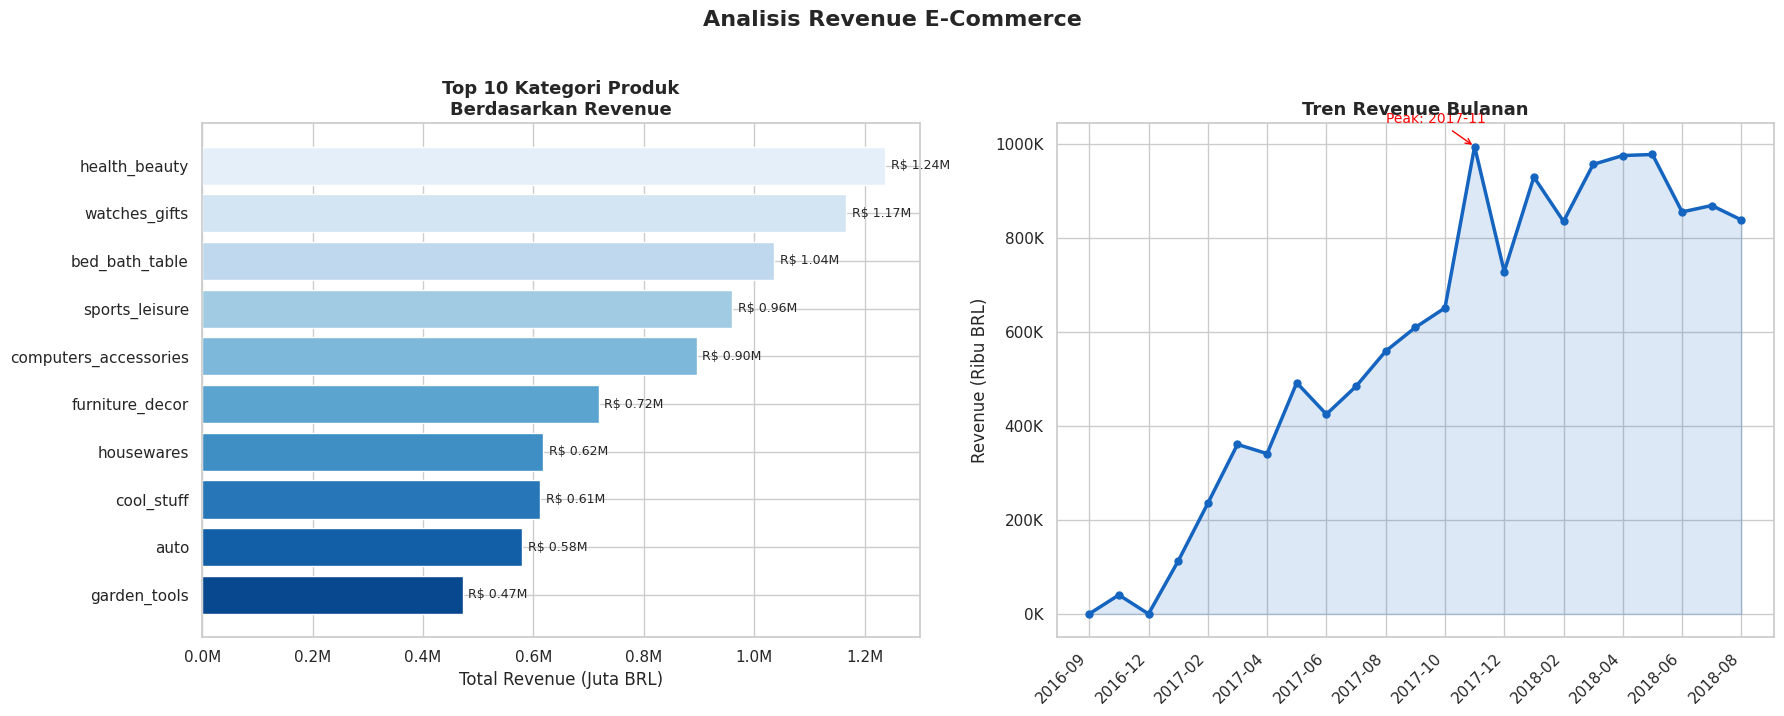

Visualisasi pertanyaan 1 disimpan.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Analisis Revenue E-Commerce', fontsize=16, fontweight='bold', y=1.02)

#Top 10 Kategori Berdasarkan Revenue
top10 = revenue_by_category.head(10)
colors = sns.color_palette('Blues_r', n_colors=10)

bars = axes[0].barh(top10['product_category_name_english'][::-1],
                    top10['total_revenue'][::-1] / 1e6,
                    color=colors)
axes[0].set_xlabel('Total Revenue (Juta BRL)', fontsize=12)
axes[0].set_title('Top 10 Kategori Produk\nBerdasarkan Revenue', fontsize=13, fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1fM'))

# Tambahkan label nilai
for bar, val in zip(bars, top10['total_revenue'][::-1]):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'R$ {val/1e6:.2f}M', va='center', fontsize=9)

#Plot 2 - Tren Revenue Bulanan -
axes[1].plot(range(len(monthly_revenue)), monthly_revenue['revenue'] / 1e3,
             marker='o', color='#1565C0', linewidth=2.5, markersize=5)
axes[1].fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'] / 1e3,
                     alpha=0.15, color='#1565C0')

# Tandai bulan tertinggi
max_idx = monthly_revenue['revenue'].idxmax()
axes[1].annotate(f"Peak: {monthly_revenue.loc[max_idx, 'order_month']}",
                 xy=(max_idx, monthly_revenue.loc[max_idx, 'revenue'] / 1e3),
                 xytext=(max_idx - 3, monthly_revenue.loc[max_idx, 'revenue'] / 1e3 + 50),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=10)

# Label sumbu x
step = max(1, len(monthly_revenue) // 8)
axes[1].set_xticks(range(0, len(monthly_revenue), step))
axes[1].set_xticklabels(monthly_revenue['order_month'][::step], rotation=45, ha='right')
axes[1].set_ylabel('Revenue (Ribu BRL)', fontsize=12)
axes[1].set_title('Tren Revenue Bulanan', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0fK'))

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi pertanyaan 1 disimpan.')

### Pertanyaan 2: Bagaimana pengaruh waktu pengiriman terhadap kepuasan pelanggan?

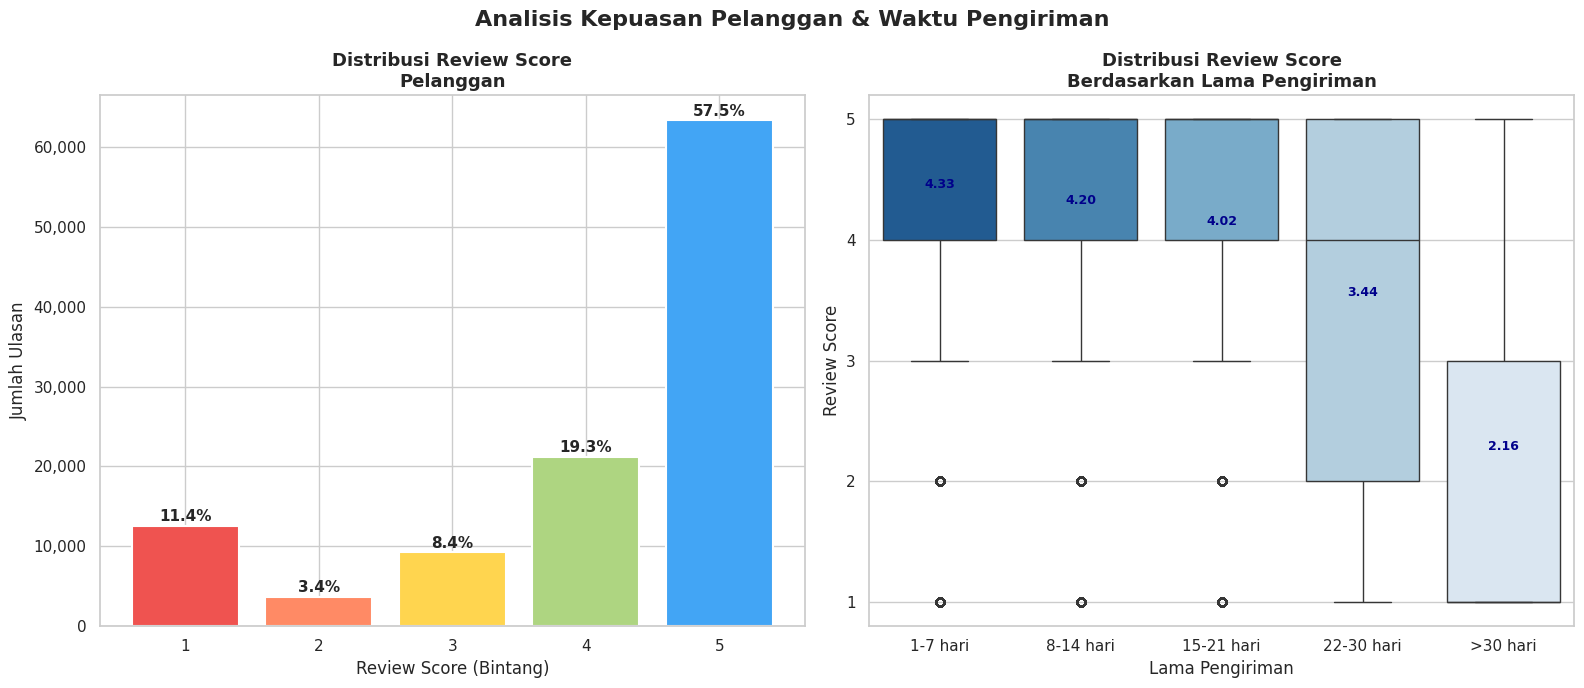

Visualisasi pertanyaan 2 disimpan.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Kepuasan Pelanggan & Waktu Pengiriman', fontsize=16, fontweight='bold')

#plot 1 - Distribusi Review Score 
score_counts = main_df['review_score'].value_counts().sort_index()
bar_colors = ['#EF5350', '#FF8A65', '#FFD54F', '#AED581', '#42A5F5']

bars = axes[0].bar(score_counts.index, score_counts.values, color=bar_colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, score_counts.values):
    pct = val / score_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].set_xlabel('Review Score (Bintang)', fontsize=12)
axes[0].set_ylabel('Jumlah Ulasan', fontsize=12)
axes[0].set_title('Distribusi Review Score\nPelanggan', fontsize=13, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 2: Boxplot Review Score vs Delivery Days
# Buat bins untuk delivery_days
plot_data = main_df[['delivery_days', 'review_score']].dropna()
plot_data['delivery_group'] = pd.cut(plot_data['delivery_days'],
                                      bins=[0, 7, 14, 21, 30, 100],
                                      labels=['1-7 hari', '8-14 hari', '15-21 hari', '22-30 hari', '>30 hari'])

sns.boxplot(data=plot_data, x='delivery_group', y='review_score',
            palette='Blues_r', ax=axes[1])

# Tambahkan rata-rata
means = plot_data.groupby('delivery_group', observed=True)['review_score'].mean()
for i, (group, mean_val) in enumerate(means.items()):
    axes[1].text(i, mean_val + 0.1, f'{mean_val:.2f}', ha='center', fontsize=9,
                 color='darkblue', fontweight='bold')

axes[1].set_xlabel('Lama Pengiriman', fontsize=12)
axes[1].set_ylabel('Review Score', fontsize=12)
axes[1].set_title('Distribusi Review Score\nBerdasarkan Lama Pengiriman', fontsize=13, fontweight='bold')
axes[1].set_yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('visualisasi_pertanyaan2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi pertanyaan 2 disimpan.')

*Insight:**
- Sebanyak -+ 57% pelanggan memberikan rating 5, menunjukkan tingkat kepuasan yang sangat tinggi secara keseluruhan.
- Tapi, terdapat sekitar -+ 11–12% pelanggan yang memberikan rating 1, yang mengindikasikan adanya segmen pelanggan dengan pengalaman negatif yang signifikan.
- Analisis berdasarkan lama pengiriman menunjukkan bahwa:
    - Pengiriman cepat (1–7 hari) memiliki rata-rata rating tertinggi (±4.3)
    - Pengiriman sangat lama (>30 hari) memiliki rata-rata rating terendah (±2.1)
- Penurunan rating terlihat signifikan terutama pada rentang pengiriman di atas 21 hari, yang menunjukkan adanya threshold kritis dalam toleransi pelanggan terhadap waktu pengiriman.

## Analisis Lanjutan (Opsional)

In [13]:
# Gabungkan dengan customers (rfm (recency, frequency, mbonetary))
rfm_df = main_df.merge(customers_df[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

snapshot_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = rfm_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('price', 'sum')
).reset_index()

print('RFM Summary:')
display(rfm.describe())

RFM Summary:


,Recency,Frequency,Monetary
count,93337.000000,93337.000000,93337.000000
mean,237.944566,1.033427,142.244665
std,152.586576,0.209120,216.946657
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.800000
50%,219.000000,1.000000,89.900000
75%,346.000000,1.000000,155.000000
max,714.000000,15.000000,13440.000000


Distribusi Segmen Pelanggan:
Segment
Potential Loyalists    39844
Loyal Customers        35067
At Risk                17865
Champions                561
Name: count, dtype: int64


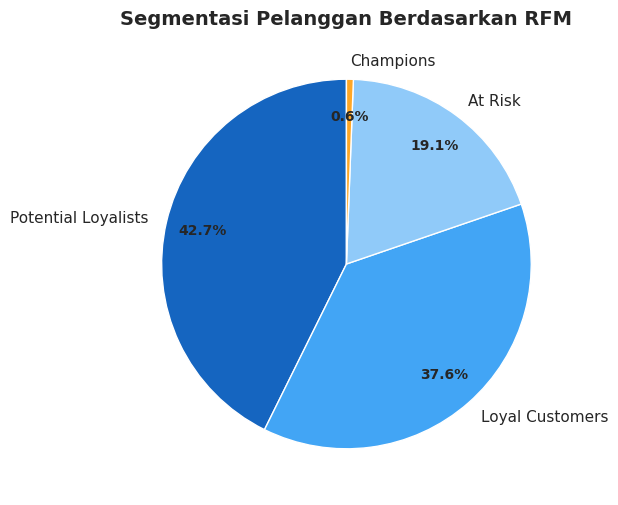

In [14]:
# Segmentasi pelanggan berdasarkan rmf Score
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.cut(rfm['Frequency'], bins=[0, 1, 2, 3, rfm['Frequency'].max()],
                         labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment_customer(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal Customers'
    elif score >= 5:
        return 'Potential Loyalists'
    elif score >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

segment_dist = rfm['Segment'].value_counts()
print('Distribusi Segmen Pelanggan:')
print(segment_dist)

# Visualisasi segmen
fig, ax = plt.subplots(figsize=(8, 6))
colors_seg = ['#1565C0', '#42A5F5', '#90CAF9', '#FFA726', '#EF5350']
wedges, texts, autotexts = ax.pie(
    segment_dist.values,
    labels=segment_dist.index,
    autopct='%1.1f%%',
    colors=colors_seg[:len(segment_dist)],
    startangle=90,
    pctdistance=0.8
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

ax.set_title('Segmentasi Pelanggan Berdasarkan RFM', fontsize=14, fontweight='bold')
plt.savefig('rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

- **Conclusion Pertanyaan 1:** 
- Kategori produk health_beauty menghasilkan revenue tertinggi, diikuti oleh watches_gifts dan bed_bath_table.
- Peningkatan revenue yang signifikan sepanjang 2017–2018, dengan puncak pada November 2017, mengindikasikan pengaruh kuat dari event promosi seperti Black Friday.
- Strategi bisnis yang disarankan adalah:
    - Fokus pada kategori high-demand untuk volume penjualan
    - Optimasi kategori high-value untuk meningkatkan margin
- **Conclusion Pertanyaan 2:** 
- Waktu pengiriman memiliki pengaruh signifikan terhadap kepuasan pelanggan.
- Pengiriman cepat (1–7 hari) menghasilkan rata-rata rating tinggi (±4.3), sedangkan pengiriman sangat lama (>30 hari) menghasilkan rating jauh lebih rendah (±2.1, bukan 3.6).
- Sekitar 57% pelanggan sangat puas (bintang 5), namun terdapat -+ 11–12% pelanggan dengan rating 1, menunjukkan adanya pengalaman buruk yang signifikan.
- Rekomendasi:
    - Optimasi logistik
    - Kurangi delivery time >21 hari
    - Tingkatkan akurasi estimasi pengiriman

end